In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ─── Simulation primitives─────────────────────────────────────
def _draw_correlated_normals(rng, n_paths: int, n_steps_mc: int, rho: float):
    """Correlated standard normals Z1, Z2 with Corr(Z1,Z2)=rho, each (n_paths, n_steps_mc)."""
    Z1 = rng.standard_normal((n_paths, n_steps_mc))
    Z2i = rng.standard_normal((n_paths, n_steps_mc))
    Z2 = rho * Z1 + np.sqrt(max(0.0, 1.0 - rho**2)) * Z2i
    return Z1, Z2

def _brownian_from_normals(Z: np.ndarray, dt: float):
    """Increments dW from standard normals Z, both (n_paths, n_steps_mc)."""
    return np.sqrt(dt) * Z

def _increments_from_normals(rho: float, dt: float, n_paths: int, n_steps_mc: int, seed=42):
    """Increments dWi from standard normals Z, (n_paths, n_steps_mc)."""
    rng = np.random.default_rng(seed)
    dW1, dW2 = _draw_correlated_normals(rng, n_paths, n_steps_mc, rho)
    dW = rng.standard_normal((n_paths, n_steps_mc))
     
    return _brownian_from_normals(dW1, dt), _brownian_from_normals(dW2, dt), _brownian_from_normals(dW, dt)


def _euler_scheme(S0, sigma0, theta0, r, kappa, nu, lam, eta, dW1, dW2, dW, dt):
    """Euler scheme for the LLH model."""
    n_paths, n_steps_mc = dW1.shape
    S = np.zeros((n_paths, n_steps_mc + 1))
    sigma = np.zeros((n_paths, n_steps_mc + 1))
    theta = np.zeros((n_paths, n_steps_mc + 1))
    S[:, 0] = S0
    sigma[:, 0] = sigma0
    theta[:, 0] = theta0
    for n in range(0, n_steps_mc):
        theta[:, n+1] = theta[:, n] + lam *dt + (theta[:, n] - theta0 + eta - lam * n *dt) * dW[:, n]
        sigma[:, n+1] = sigma[:, n] + kappa * (theta[:, n] - sigma[:, n]) * dt + nu * dW2[:, n]
        S[:, n+1] = S[:, n] * np.exp((r - 0.5 * sigma[:, n]**2) * dt + sigma[:, n] * dW1[:, n])
    return S, sigma, theta

def simulate_prices(S0, T, n_steps_mc, n_paths, 
                r, rho, kappa, nu, sigma0, theta0, lam, eta, 
                scheme: str = 'euler', seed=42
    ) -> dict:
        """Simulate LLH price and volatility paths via Euler discretization.
        """
        dt = T / n_steps_mc
        dW1, dW2, dW = _increments_from_normals(rho, dt, n_paths, n_steps_mc, seed)
        S, _, _ =_euler_scheme(S0, sigma0, theta0, r, kappa, nu, lam, eta, dW1, dW2, dW, dt)

        return {"S": S, "dt": dt}

def price_call_mc(paths, K, T, r=None):
    """Monte Carlo European call price from simulated terminal values.
    """
    n_paths = paths.shape[0]
    disc = np.exp(-r * T)
    Y = disc * np.maximum(paths[:, -1] - K, 0.0)
    price = Y.mean()
    std_err = Y.std(ddof=1) / np.sqrt(n_paths)
    ci95 = (price - 1.96*std_err, price + 1.96*std_err)
    return {
        'price': price,
        'std_err': std_err,
        'ci_95': ci95,
        'n_paths': n_paths
    }

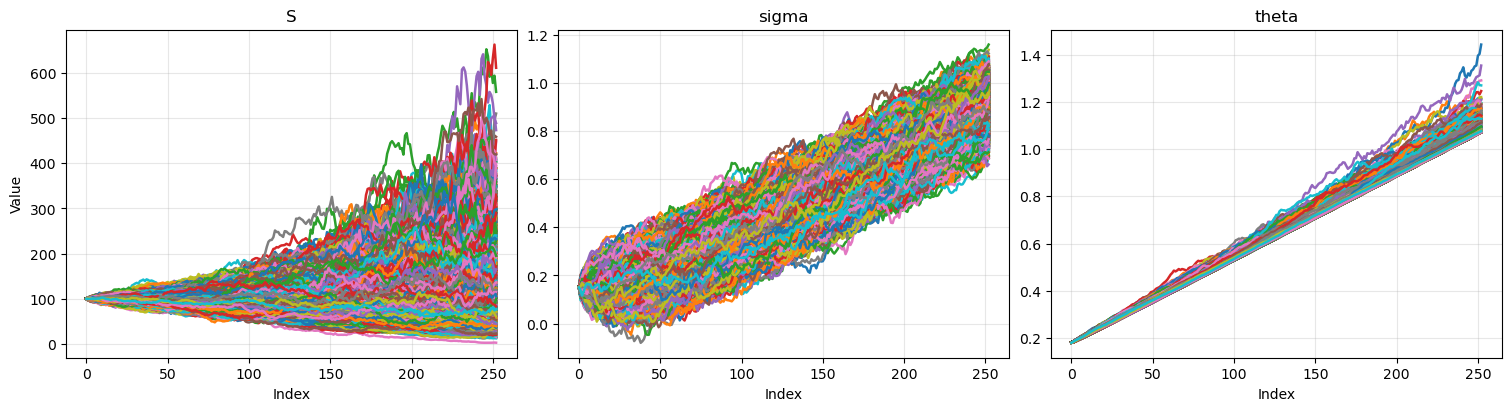

In [14]:
r, rho, kappa, nu, sigma0, theta0, lam, eta = 0.01, -0.2, 5, 0.2, 0.15, 0.18, 0.9, 0.01
S0, T, n_steps_mc, n_paths = 100.0, 1.0, 252, 10000

dt = T / n_steps_mc
dW1, dW2, dW = _increments_from_normals(rho, dt, n_paths, n_steps_mc)
S, sigma, theta =_euler_scheme(S0, sigma0, theta0, r, kappa, nu, lam, eta, dW1, dW2, dW, dt)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

series = [S.T, sigma.T, theta.T]
titles = ["S", "sigma", "theta"]

for ax, y, title in zip(axes, series, titles):
    ax.plot(np.arange(0, n_steps_mc + 1), y, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Index")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Value")
plt.show()

In [15]:
n_paths = 10000

S0, K = 100.0, 100.0
paths = simulate_prices(S0, T, n_steps_mc, n_paths, r, rho, kappa, nu, sigma0, theta0, lam, eta)['S']
price_call_mc(paths, K, T, r)

{'price': 21.629209735629917,
 'std_err': 0.43158658558642216,
 'ci_95': (20.78330002788053, 22.475119443379306),
 'n_paths': 10000}

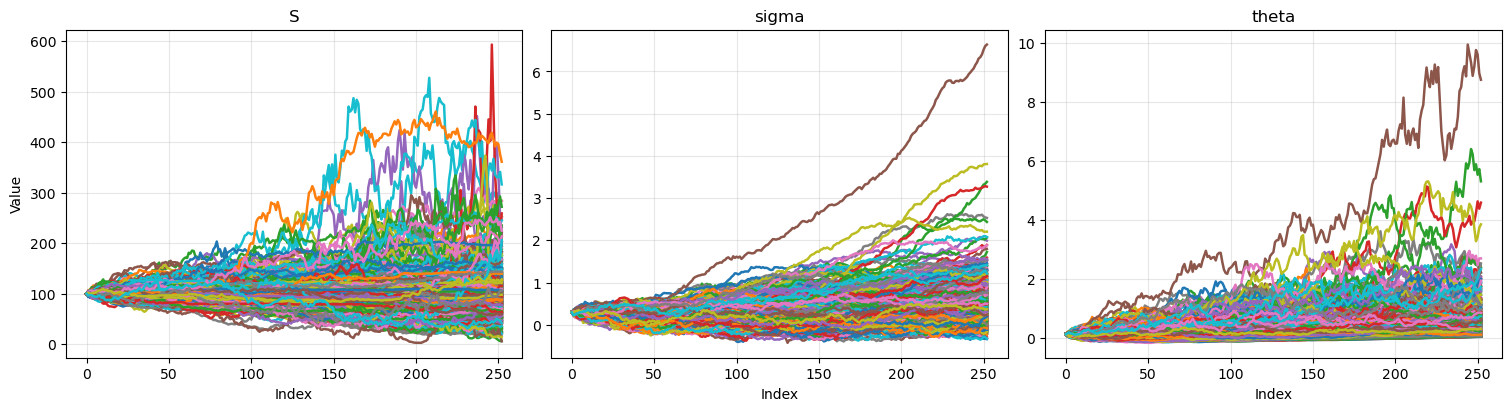

In [7]:
r, rho, kappa, nu, sigma0, theta0, lam, eta = 0.01, 0.1691, 4.9394, 0.3943, 0.2924, 0.1319, 0.3115, 0.4112

S0, T, n_steps_mc, n_paths = 100.0, 1.0, 252, 1000

dt = T / n_steps_mc
dW1, dW2, dW = _increments_from_normals(rho, dt, n_paths, n_steps_mc)
S, sigma, theta =_euler_scheme(S0, sigma0, theta0, r, kappa, nu, lam, eta, dW1, dW2, dW, dt)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

series = [S.T, sigma.T, theta.T]
titles = ["S", "sigma", "theta"]

for ax, y, title in zip(axes, series, titles):
    ax.plot(np.arange(0, n_steps_mc + 1), y, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Index")
    ax.grid(alpha=0.3)
    axes[0].set_ylabel("Value")

plt.show()

In [ ]:
n_paths = 500000

S0, K = 100.0, 100.0
paths = simulate_prices(S0, T, n_steps_mc, n_paths, r, rho, kappa, nu, sigma0, theta0, lam, eta)['S']
price_call_mc(paths, K, T, r)

## Batched, memory-bounded Euler simulation

Draws BM increments and rolls `(S, σ, θ)` as 1D state vectors within per-batch scopes. Memory ≈ `batch_size · n_steps_mc · 8·6 B`; independent of `n_paths`.

In [ ]:
def _euler_step_inplace(S, sigma, theta, dW1_n, dW2_n, dW_n, n, dt,
                        r, kappa, nu, lam, eta, theta0):
    """Advance 1D state (S, sigma, theta) by one Euler step in place.

    Ordering matters: S uses old sigma, sigma uses old theta, theta updates itself.
    """
    S *= np.exp((r - 0.5 * sigma * sigma) * dt + sigma * dW1_n)
    sigma += kappa * (theta - sigma) * dt + nu * dW2_n
    theta += lam * dt + (theta - theta0 + eta - lam * n * dt) * dW_n


def simulate_terminal_batched(S0, T, n_steps_mc, n_paths,
                              r, rho, kappa, nu, sigma0, theta0, lam, eta,
                              batch_size: int = 20_000, seed: int = 42) -> np.ndarray:
    """Batched LLH Euler simulation returning only S_T, shape (n_paths,).

    Per-batch peak memory: 3 BM arrays + 3 state vectors
        ≈ 3 * batch_size * n_steps_mc * 8 B + 3 * batch_size * 8 B.
    BM arrays and state are released at the end of each batch iteration.

    RNG: each batch gets an independent substream via SeedSequence.spawn(),
    so results are reproducible but independent across batches.
    """
    dt = T / n_steps_mc
    sqdt = np.sqrt(dt)
    sqrt_1mrho2 = np.sqrt(max(0.0, 1.0 - rho ** 2))
    n_batches = (n_paths + batch_size - 1) // batch_size
    sub_seeds = np.random.SeedSequence(seed).spawn(n_batches)

    chunks = []
    remaining = n_paths
    for b in range(n_batches):
        bs = min(batch_size, remaining)
        remaining -= bs
        rng = np.random.default_rng(sub_seeds[b])

        Z1 = rng.standard_normal((bs, n_steps_mc))
        Z2i = rng.standard_normal((bs, n_steps_mc))
        Z2 = rho * Z1 + sqrt_1mrho2 * Z2i
        Zi = rng.standard_normal((bs, n_steps_mc))
        dW1 = sqdt * Z1
        dW2 = sqdt * Z2
        dW  = sqdt * Zi
        del Z1, Z2, Z2i, Zi

        S     = np.full(bs, S0,     dtype=np.float64)
        sigma = np.full(bs, sigma0, dtype=np.float64)
        theta = np.full(bs, theta0, dtype=np.float64)
        for n in range(n_steps_mc):
            _euler_step_inplace(S, sigma, theta,
                                dW1[:, n], dW2[:, n], dW[:, n],
                                n, dt, r, kappa, nu, lam, eta, theta0)
        chunks.append(S.copy())
        del dW1, dW2, dW, S, sigma, theta

    return np.concatenate(chunks)


def price_call_mc_terminal(S_T, K, T, r):
    """European call MC estimator from a 1D terminal-price vector."""
    n_paths = S_T.shape[0]
    disc = np.exp(-r * T)
    Y = disc * np.maximum(S_T - K, 0.0)
    price = Y.mean()
    std_err = Y.std(ddof=1) / np.sqrt(n_paths)
    ci95 = (price - 1.96 * std_err, price + 1.96 * std_err)
    return {'price': price, 'std_err': std_err, 'ci_95': ci95, 'n_paths': n_paths}

In [ ]:
# Batched pricing demo — Table 1 params
r, rho, kappa, nu, sigma0, theta0, lam, eta = 0.01, -0.2, 5, 0.2, 0.15, 0.18, 0.9, 0.01
S0, K, T, n_steps_mc, n_paths = 100.0, 100.0, 1.0, 252, 500_000

S_T = simulate_terminal_batched(S0, T, n_steps_mc, n_paths,
                                r, rho, kappa, nu, sigma0, theta0, lam, eta,
                                batch_size=20_000, seed=42)
price_call_mc_terminal(S_T, K, T, r)

In [ ]:
# Batched pricing demo — Table 2 params
r, rho, kappa, nu, sigma0, theta0, lam, eta = 0.01, 0.1691, 4.9394, 0.3943, 0.2924, 0.1319, 0.3115, 0.4112
S0, K, T, n_steps_mc, n_paths = 100.0, 100.0, 1.0, 252, 500_000

S_T = simulate_terminal_batched(S0, T, n_steps_mc, n_paths,
                                r, rho, kappa, nu, sigma0, theta0, lam, eta,
                                batch_size=20_000, seed=42)
price_call_mc_terminal(S_T, K, T, r)

In [ ]:
# Memory / speed benchmark — full-grid vs batched, matched n_paths
import time, tracemalloc

r, rho, kappa, nu, sigma0, theta0, lam, eta = 0.01, -0.2, 5, 0.2, 0.15, 0.18, 0.9, 0.01
S0, K, T, n_steps_mc = 100.0, 100.0, 1.0, 252
n_paths_bench = 100_000

# Full-grid path
tracemalloc.start()
t0 = time.perf_counter()
paths = simulate_prices(S0, T, n_steps_mc, n_paths_bench,
                        r, rho, kappa, nu, sigma0, theta0, lam, eta)['S']
full_price = price_call_mc(paths, K, T, r)['price']
full_time = time.perf_counter() - t0
_, full_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
del paths

# Batched path
tracemalloc.start()
t0 = time.perf_counter()
S_T = simulate_terminal_batched(S0, T, n_steps_mc, n_paths_bench,
                                r, rho, kappa, nu, sigma0, theta0, lam, eta,
                                batch_size=20_000, seed=42)
batched_price = price_call_mc_terminal(S_T, K, T, r)['price']
batched_time = time.perf_counter() - t0
_, batched_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"full-grid : price={full_price:.4f}  time={full_time:.2f}s  peak={full_peak/1e6:.1f} MB")
print(f"batched   : price={batched_price:.4f}  time={batched_time:.2f}s  peak={batched_peak/1e6:.1f} MB")

In [19]:
# Compare batched alt-θ-SDE pricer vs priceModels MC — two param sets, K sweep
import sys
if '../src' not in sys.path:
    sys.path.insert(0, '../src')
import priceModels as pm

S0, T, n_steps_mc, n_paths_cmp = 100.0, 1.0, 252, 250_000
K_grid = np.arange(90.0, 110.0 + 1e-9, 2.0)

param_sets = {
    "Table 1": dict(r=0.01, rho=-0.2,   kappa=5.0,    nu=0.2,    sigma0=0.15,   theta0=0.18,   lam=0.9,    eta=0.01),
    "Table 2": dict(r=0.01, rho=0.1691, kappa=4.9394, nu=0.3943, sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112),
}

results = {}
for name, p in param_sets.items():
    # Single draw per method, reused across strikes (S_T / paths don't depend on K)
    S_T = simulate_terminal_batched(S0, T, n_steps_mc, n_paths_cmp,
                                    p['r'], p['rho'], p['kappa'], p['nu'],
                                    p['sigma0'], p['theta0'], p['lam'], p['eta'],
                                    batch_size=20_000, seed=42)
    model = pm.ImprovedSteinStein(r=p['r'], sigma0=p['sigma0'], theta0=p['theta0'],
                                  rho=p['rho'], kappa=p['kappa'], lam=p['lam'],
                                  nu=p['nu'], eta=p['eta'], seed=42)
    paths_pm = model.simulate_prices(S0=S0, T=T, n_steps_mc=n_steps_mc,
                                     n_paths=n_paths_cmp, scheme='euler')['S']

    lab_price = np.empty_like(K_grid); lab_se = np.empty_like(K_grid)
    pm_price  = np.empty_like(K_grid); pm_se  = np.empty_like(K_grid)
    for i, K in enumerate(K_grid):
        rl = price_call_mc_terminal(S_T, K, T, p['r'])
        rp = pm.price_call_mc(paths_pm, K, T, r=p['r'])
        lab_price[i], lab_se[i] = rl['price'], rl['std_err']
        pm_price[i],  pm_se[i]  = rp['price'], rp['std_err']

    results[name] = dict(lab_price=lab_price, lab_se=lab_se,
                         pm_price=pm_price,  pm_se=pm_se)
    del S_T, paths_pm

{k: {'lab_atm': v['lab_price'][K_grid == 100][0],
     'pm_atm':  v['pm_price'][K_grid == 100][0]} for k, v in results.items()}

{'Table 1': {'lab_atm': 21.281712890630402, 'pm_atm': 21.388866203808423},
 'Table 2': {'lab_atm': 12.992946299994268, 'pm_atm': 13.016380008043956}}

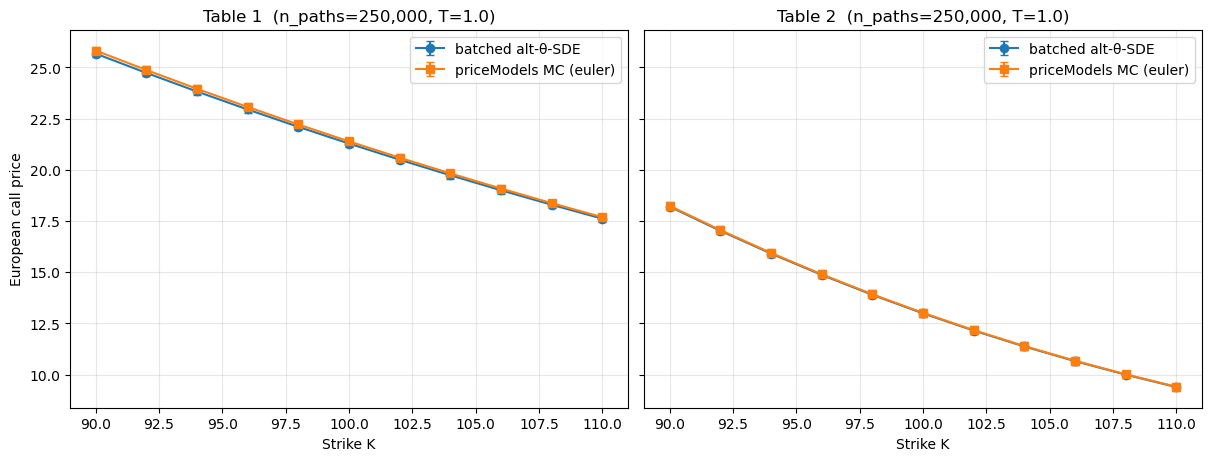

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True, sharey=True)

for ax, (name, res) in zip(axes, results.items()):
    ax.errorbar(K_grid, res['lab_price'], yerr=1.96 * res['lab_se'],
                marker='o', capsize=3, label='batched alt-θ-SDE')
    ax.errorbar(K_grid, res['pm_price'],  yerr=1.96 * res['pm_se'],
                marker='s', capsize=3, label='priceModels MC (euler)')
    ax.set_title(f"{name}  (n_paths={n_paths_cmp:,}, T={T})")
    ax.set_xlabel("Strike K")
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("European call price")
plt.show()